# 01 — Exploración de los datos IEEE-CIS

En este primer notebook buscamos entender con qué datos vamos a trabajar antes de tomar decisiones de preparación o modelado. Nos interesa responder cinco preguntas: ¿la unión de las tablas conserva todas las transacciones?, ¿qué tan desbalanceada está la variable `isFraud`?, ¿cómo se distribuye `TransactionAmt`?, ¿qué cambios aparecen a lo largo del tiempo? y ¿qué tan grave es la ausencia de información?

Este paso es importante para nuestro proyecto porque la decisión final no dependerá solamente de clasificar una operación como fraude. También utilizaremos el monto de cada transacción como aproximación de la pérdida asociada a dejar pasar un fraude. En este notebook todavía no imputamos, codificamos ni entrenamos modelos: primero queremos conocer el conjunto y justificar las decisiones que tomaremos después.

## 1. Preparación del análisis

Los archivos originales están en `data/raw/` y no se modifican desde el notebook. Dejamos la instalación de dependencias y la descarga de Kaggle fuera del análisis para que una celda no cambie silenciosamente el entorno de otra persona.

La primera celda localiza la raíz del repositorio aunque Jupyter se abra desde la carpeta principal o desde `notebooks/`. Después importa únicamente las bibliotecas necesarias para esta exploración.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_cost.data import load_ieee_cis, missingness_summary
from pathlib import Path

def find_project_root(start=Path.cwd()):
    """Encuentra la raíz buscando las carpetas data y notebooks."""
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto. Abra Jupyter dentro del repositorio.")

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"

RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 20)
sns.set_theme(style="whitegrid")
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datos originales: {DATA_RAW}")

Raíz del proyecto: C:\Users\Milton Cuervo\Documents\IEEE-CIS Fraud Detection-PI2
Datos originales: C:\Users\Milton Cuervo\Documents\IEEE-CIS Fraud Detection-PI2\data\raw


## 2. Carga, unión y comprobaciones de integridad

`train_transaction.csv` contiene la etiqueta `isFraud`, el monto, el tiempo y las variables asociadas a la transacción. `train_identity.csv` agrega información de dispositivo e identidad, pero solo existe para una parte de los registros.

Unimos ambas tablas con un `left join` por `TransactionID`. Elegimos este tipo de unión porque nuestra unidad de análisis es la transacción etiquetada: eliminar operaciones sin identidad cambiaría la población del estudio. La función de carga también comprueba que el identificador sea único en cada tabla y que la unión no aumente ni reduzca el número de transacciones.

In [2]:
transactions, identity, df = load_ieee_cis(DATA_RAW)

coverage = identity["TransactionID"].nunique() / transactions["TransactionID"].nunique()
pd.DataFrame({
    "filas": [len(transactions), len(identity), len(df)],
    "columnas": [transactions.shape[1], identity.shape[1], df.shape[1]],
}, index=["transaction", "identity", "union"]), coverage

(              filas  columnas
 transaction  590540       394
 identity     144233        41
 union        590540       434,
 0.2442391709283029)

## 3. Variable objetivo y desbalance

Ahora revisamos cuántas transacciones legítimas y fraudulentas hay. No hacemos esta cuenta solo para describir los datos: el desbalance define qué métricas serán útiles más adelante.

Con una proporción pequeña de fraude, un modelo podría obtener una exactitud alta prediciendo casi todo como legítimo. Por esa razón no utilizaremos `accuracy` como resultado principal. Nos interesarán AUC-PR y recall para describir la capacidad predictiva, pero la comparación central se hará con costo total y ahorro.

,n,proporción
isFraud,,
0,569877,0.96501
1,20663,0.03499


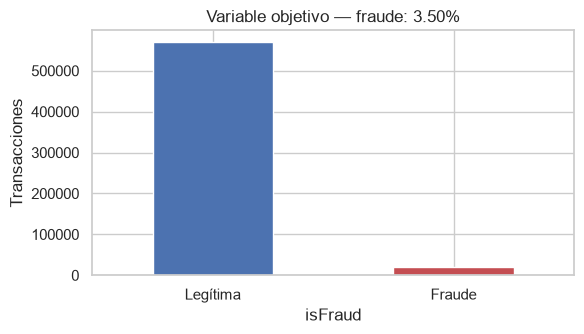

In [3]:
class_counts = df["isFraud"].value_counts().sort_index()
fraud_rate = df["isFraud"].mean()
target_summary = pd.DataFrame({"n": class_counts, "proporción": class_counts / len(df)})
display(target_summary)
target_summary.to_csv(RESULTS_TABLES / "eda_distribucion_objetivo.csv")

ax = class_counts.rename(index={0: "Legítima", 1: "Fraude"}).plot.bar(
    figsize=(6, 3.5), color=["#4C72B0", "#C44E52"], rot=0
)
ax.set(title=f"Variable objetivo — fraude: {fraud_rate:.2%}", ylabel="Transacciones")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "eda_distribucion_objetivo.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. `TransactionAmt` y la exposición económica

En la matriz de costos del proyecto, `TransactionAmt` aproxima el costo de aprobar una operación que realmente era fraude. Antes de usarlo necesitamos observar su escala, asimetría y valores extremos.

Comparamos la distribución en escala original y logarítmica. La transformación logarítmica se usa solo para visualizar mejor la concentración; no reemplaza los montos originales en el cálculo económico. También comparamos ambas clases para saber si contar fraudes y sumar exposición económica cuentan historias distintas.

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


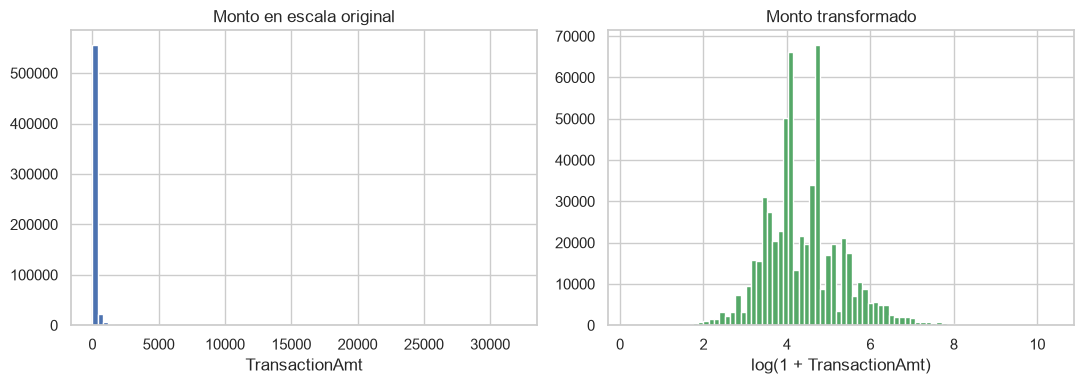

In [4]:
display(df.groupby("isFraud")["TransactionAmt"].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["TransactionAmt"], bins=80, color="#4C72B0")
axes[0].set(title="Monto en escala original", xlabel="TransactionAmt")
axes[1].hist(np.log1p(df["TransactionAmt"]), bins=80, color="#55A868")
axes[1].set(title="Monto transformado", xlabel="log(1 + TransactionAmt)")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "eda_distribucion_montos.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Estructura temporal

`TransactionDT` es un contador de segundos desde un origen que no fue publicado. Por eso no afirmamos que una observación corresponde a una fecha u hora civil concreta. Sí podemos usar el orden y las diferencias temporales para simular el escenario real: entrenar con operaciones pasadas y evaluar sobre operaciones posteriores.

Dividimos el periodo completo en diez intervalos únicamente para explorarlo. Estos intervalos todavía no son las particiones definitivas de entrenamiento, validación y prueba.

,transacciones,tasa_fraude
TransactionDT,,
"(-0.182, 18.2]",76210,0.026834
"(18.2, 36.4]",79510,0.026890
"(36.4, 54.6]",52200,0.040192
"(54.6, 72.8]",55983,0.044371
"(72.8, 91.0]",56024,0.037787
"(91.0, 109.2]",60888,0.034966
"(109.2, 127.399]",57310,0.041057
"(127.399, 145.599]",47778,0.036356
"(145.599, 163.799]",54101,0.030628


Orden temporal original: True
Duración aproximada (días): 182.0


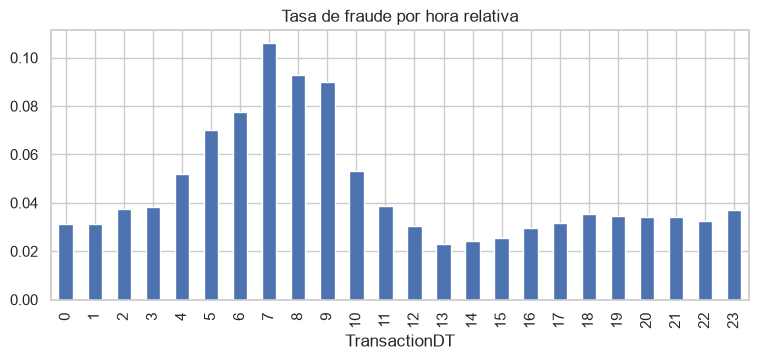

In [5]:
elapsed_days = (df["TransactionDT"] - df["TransactionDT"].min()) / 86_400
relative_hour = (df["TransactionDT"] // 3_600) % 24
temporal_bins = pd.cut(elapsed_days, bins=10, duplicates="drop")

temporal_summary = df.groupby(temporal_bins, observed=True).agg(
    transacciones=("isFraud", "size"), tasa_fraude=("isFraud", "mean")
)
display(temporal_summary)
print("Orden temporal original:", df["TransactionDT"].is_monotonic_increasing)
print("Duración aproximada (días):", round(elapsed_days.max(), 1))
df.groupby(relative_hour)["isFraud"].mean().plot.bar(
    figsize=(9, 3.5), title="Tasa de fraude por hora relativa"
);

## 6. Ausencia y variables categóricas iniciales

La ausencia aparece por dos razones distintas. Algunas columnas ya tienen faltantes dentro de su tabla original; otras quedan vacías después de la unión porque `train_identity` solo cubre una fracción de las transacciones. No deberíamos tratar ambos casos automáticamente como si fueran el mismo problema.

También revisamos la cardinalidad de algunas variables que podremos explicar durante una presentación: producto, tipo de tarjeta, correo y dispositivo. Por ahora solo las describimos; la codificación se definirá después de separar los bloques temporales.

In [6]:
display(missingness_summary(transactions).head(15))
display(missingness_summary(identity).head(15))

key_categoricals = ["ProductCD", "card4", "card6", "P_emaildomain", "DeviceType"]
categorical_summary = pd.DataFrame({
    column: {
        "cardinalidad": df[column].nunique(dropna=True),
        "ausencia": df[column].isna().mean(),
    }
    for column in key_categoricals if column in df
}).T
display(categorical_summary.sort_values("cardinalidad", ascending=False))

,n_missing,missing_rate,dtype
dist2,552913,0.936284,float64
D7,551623,0.934099,float64
D13,528588,0.895093,float64
D14,528353,0.894695,float64
D12,525823,0.890410,float64
D6,517353,0.876068,float64
D8,515614,0.873123,float64
D9,515614,0.873123,float64
V154,508595,0.861237,float64
V153,508595,0.861237,float64


,n_missing,missing_rate,dtype
id_24,139486,0.967088,float64
id_25,139101,0.964419,float64
id_07,139078,0.964259,float64
id_08,139078,0.964259,float64
id_21,139074,0.964231,float64
id_26,139070,0.964204,float64
id_22,139064,0.964162,float64
id_27,139064,0.964162,object
id_23,139064,0.964162,object
id_18,99120,0.687221,float64


,cardinalidad,ausencia
P_emaildomain,59.0,0.159949
ProductCD,5.0,0.000000
card4,4.0,0.002670
card6,4.0,0.002660
DeviceType,2.0,0.761557


## 7. Perfil general de las variables

Con 434 columnas después de la unión, revisar una por una no es práctico. Construimos un perfil con tipo de dato, cantidad de valores únicos y proporción de ausencia. Esto nos permite identificar grupos que necesitarán tratamientos diferentes.

No vamos a asumir que toda columna numérica es continua: varias variables son identificadores o códigos almacenados como números. Tampoco eliminaremos una columna únicamente por tener alta cardinalidad o muchos faltantes; primero debemos comprobar su estabilidad y utilidad dentro de las particiones temporales.

In [7]:
column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(dropna=True),
    "proporcion_unicos": df.nunique(dropna=True) / len(df),
    "ausencia": df.isna().mean(),
})

type_summary = (column_profile.groupby("dtype")
                .agg(columnas=("dtype", "size"),
                     ausencia_mediana=("ausencia", "median"),
                     cardinalidad_mediana=("n_unicos", "median"))
                .sort_values("columnas", ascending=False))
display(type_summary)
display(column_profile.sort_values("ausencia", ascending=False).head(20))
print("Columnas constantes o completamente ausentes:",
      int((column_profile["n_unicos"] <= 1).sum()))

,columnas,ausencia_mediana,cardinalidad_mediana
dtype,,,
float64,399,0.472935,46.0
object,31,0.761261,2.0
int64,4,0.000000,293451.0


,dtype,n_unicos,proporcion_unicos,ausencia
id_24,float64,12,0.000020,0.991962
id_25,float64,341,0.000577,0.991310
id_07,float64,84,0.000142,0.991271
id_08,float64,94,0.000159,0.991271
id_21,float64,490,0.000830,0.991264
id_26,float64,95,0.000161,0.991257
id_27,object,2,0.000003,0.991247
id_23,object,3,0.000005,0.991247
id_22,float64,25,0.000042,0.991247
dist2,float64,1751,0.002965,0.936284


Columnas constantes o completamente ausentes: 0


### Lo que entendemos del perfil

La mayoría de las variables son numéricas, pero la ausencia es extensa y no está distribuida de manera uniforme. Esto descarta una estrategia simple como “rellenar todo con cero” sin revisar el significado de cada grupo. También observamos que no hay columnas completamente constantes en el conjunto unido, de modo que por ahora no tenemos una eliminación automática por falta total de variación.

## 8. Cobertura de identidad y relación con fraude

Creamos `has_identity` solamente para estudiar si la disponibilidad de la tabla de identidad está asociada con la clase. Este indicador no dice que una identidad sea confiable ni que cause fraude; solo indica que existe una fila correspondiente en `train_identity`.

Comparamos tanto la cobertura dentro de cada clase como la tasa de fraude dentro de los grupos con y sin identidad. Mostrar ambos sentidos evita interpretar una sola proporción fuera de contexto.

In [8]:
identity_ids = set(identity["TransactionID"])
has_identity = df["TransactionID"].isin(identity_ids)
identity_by_class = pd.crosstab(
    df["isFraud"], has_identity, normalize="index"
).rename(columns={False: "sin_identity", True: "con_identity"})
display(identity_by_class)

fraud_by_identity = df.assign(has_identity=has_identity).groupby(
    "has_identity"
)["isFraud"].agg(["size", "sum", "mean"])
fraud_by_identity.columns = ["transacciones", "fraudes", "tasa_fraude"]
display(fraud_by_identity)

identity_by_class.to_csv(RESULTS_TABLES / "eda_cobertura_identidad_por_clase.csv")
fraud_by_identity.to_csv(RESULTS_TABLES / "eda_fraude_segun_identidad.csv")

TransactionID,sin_identity,con_identity
isFraud,,
0,0.766765,0.233235
1,0.452258,0.547742


,transacciones,fraudes,tasa_fraude
has_identity,,,
False,446307,9345,0.020939
True,144233,11318,0.078470


## 9. Dimensión económica del fraude observado

La tasa de fraude cuenta eventos, pero nuestro problema necesita considerar cuánto dinero está expuesto. Calculamos monto total, promedio, mediana y percentiles por clase. También medimos qué parte del monto fraudulento está concentrada en el 1% de fraudes de mayor valor.

Tomamos `TransactionAmt` como una aproximación de pérdida potencial, no como una pérdida bancaria confirmada. El dataset no informa recuperaciones, contracargos ni márgenes, por lo que esta limitación debe aparecer en el informe final.

In [9]:
amount_by_class = df.groupby("isFraud")["TransactionAmt"].agg(
    transacciones="size",
    monto_total="sum",
    monto_promedio="mean",
    monto_mediano="median",
    p90=lambda s: s.quantile(0.90),
    p99=lambda s: s.quantile(0.99),
    monto_maximo="max",
)
display(amount_by_class)
amount_by_class.to_csv(RESULTS_TABLES / "eda_montos_por_clase.csv")

fraud_amount_share = (
    df.loc[df["isFraud"].eq(1), "TransactionAmt"].sum()
    / df["TransactionAmt"].sum()
)
print(f"Fracción del monto total asociada a fraude: {fraud_amount_share:.2%}")

fraud_amount = df.loc[df["isFraud"].eq(1), "TransactionAmt"].sort_values(ascending=False)
top_1_share = fraud_amount.head(max(1, int(len(fraud_amount) * 0.01))).sum() / fraud_amount.sum()
print(f"Concentración del monto fraudulento en el 1 % de fraudes de mayor monto: {top_1_share:.2%}")

,transacciones,monto_total,monto_promedio,monto_mediano,p90,p99,monto_maximo
isFraud,,,,,,,
0,569877,7.665510e+07,134.511665,68.5,267.112,1104.0,31937.391
1,20663,3.083845e+06,149.244779,75.0,335.000,994.0,5191.000


Fracción del monto total asociada a fraude: 3.87%
Concentración del monto fraudulento en el 1 % de fraudes de mayor monto: 10.63%


### Qué implica para nuestra evaluación

Los fraudes presentan un monto mediano ligeramente mayor, pero existe dispersión amplia en ambas clases. Además, el 1% de fraudes con mayor monto concentra 10,63% de la exposición fraudulenta. Esto nos indica que el recall por sí solo no distingue entre fraudes pequeños y grandes, pero tampoco podemos decir que todo el resultado económico dependa de unos pocos casos. Más adelante reportaremos recall y costo juntos y haremos sensibilidad a valores extremos.

## 10. Cambios durante el periodo observado

Además del orden cronológico, nos interesa saber si cambian el volumen, la tasa de fraude y el monto típico. Agrupamos por décimos del periodo para obtener una primera señal de estabilidad.

Este análisis no prueba formalmente deriva de concepto, porque no estudia todavía la relación completa entre atributos y etiqueta. Sí muestra si una partición aleatoria ocultaría diferencias que un modelo desplegado tendría que enfrentar en el futuro.

,transacciones,fraudes,tasa_fraude,monto_mediano,monto_total
periodo,,,,,
"(-0.182, 18.2]",76210,2045,0.026834,72.950,9.739283e+06
"(18.2, 36.4]",79510,2138,0.026890,75.000,1.024291e+07
"(36.4, 54.6]",52200,2098,0.040192,61.950,7.038056e+06
"(54.6, 72.8]",55983,2484,0.044371,63.924,7.673738e+06
"(72.8, 91.0]",56024,2117,0.037787,67.950,8.018757e+06
"(91.0, 109.2]",60888,2129,0.034966,74.679,8.479714e+06
"(109.2, 127.399]",57310,2353,0.041057,68.950,7.783981e+06
"(127.399, 145.599]",47778,1737,0.036356,63.324,6.362237e+06
"(145.599, 163.799]",54101,1657,0.030628,69.000,7.414665e+06


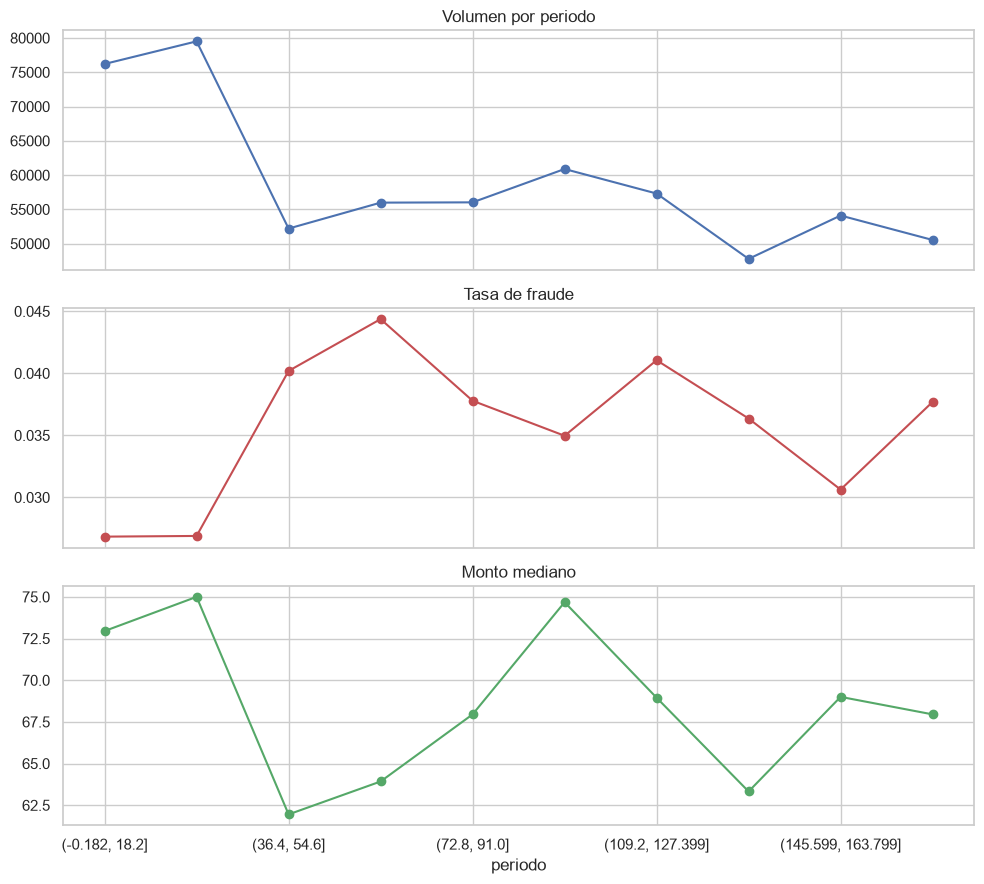

In [10]:
temporal_economic = df.assign(periodo=temporal_bins).groupby(
    "periodo", observed=True
).agg(
    transacciones=("isFraud", "size"),
    fraudes=("isFraud", "sum"),
    tasa_fraude=("isFraud", "mean"),
    monto_mediano=("TransactionAmt", "median"),
    monto_total=("TransactionAmt", "sum"),
)
display(temporal_economic)
temporal_economic.to_csv(RESULTS_TABLES / "eda_resumen_temporal.csv")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
temporal_economic["transacciones"].plot(ax=axes[0], marker="o", title="Volumen por periodo")
temporal_economic["tasa_fraude"].plot(ax=axes[1], marker="o", color="#C44E52", title="Tasa de fraude")
temporal_economic["monto_mediano"].plot(ax=axes[2], marker="o", color="#55A868", title="Monto mediano")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "eda_evolucion_temporal.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Variables categóricas: tamaño del grupo y tasa de fraude

Para cada categoría mostramos número de transacciones, fraudes y tasa de fraude. Consideramos necesario mostrar el tamaño del grupo porque una tasa llamativa basada en pocas observaciones puede ser inestable.

Estas comparaciones utilizan todo el conjunto únicamente como exploración. No vamos a convertir las tasas globales en variables ni a escoger categorías mirando el futuro. Si posteriormente usamos codificación basada en la etiqueta, deberá aprenderse exclusivamente con entrenamiento.

In [11]:
def summarize_category(frame, column, top=12):
    summary = (frame.assign(category=frame[column].astype("string").fillna("<AUSENTE>"))
               .groupby("category")["isFraud"]
               .agg(transacciones="size", fraudes="sum", tasa_fraude="mean")
               .sort_values("transacciones", ascending=False)
               .head(top))
    summary["proporcion_datos"] = summary["transacciones"] / len(frame)
    return summary

for column in key_categoricals:
    if column in df:
        print(f"\n{column}")
        display(summarize_category(df, column))


ProductCD


,transacciones,fraudes,tasa_fraude,proporcion_datos
category,,,,
W,439670,8969,0.020399,0.744522
C,68519,8008,0.116873,0.116028
R,37699,1426,0.037826,0.063838
H,33024,1574,0.047662,0.055922
S,11628,686,0.058996,0.019690



card4


,transacciones,fraudes,tasa_fraude,proporcion_datos
category,,,,
visa,384767,13373,0.034756,0.651551
mastercard,189217,6496,0.034331,0.320414
american express,8328,239,0.028698,0.014102
discover,6651,514,0.077282,0.011263
<AUSENTE>,1577,41,0.025999,0.002670



card6


,transacciones,fraudes,tasa_fraude,proporcion_datos
category,,,,
debit,439938,10674,0.024263,0.744976
credit,148986,9950,0.066785,0.252288
<AUSENTE>,1571,39,0.024825,0.002660
debit or credit,30,0,0.000000,0.000051
charge card,15,0,0.000000,0.000025



P_emaildomain


,transacciones,fraudes,tasa_fraude,proporcion_datos
category,,,,
gmail.com,228355,9943,0.043542,0.386688
yahoo.com,100934,2297,0.022757,0.170918
<AUSENTE>,94456,2790,0.029538,0.159949
hotmail.com,45250,2396,0.052950,0.076625
anonymous.com,36998,859,0.023217,0.062651
aol.com,28289,617,0.021811,0.047904
comcast.net,7888,246,0.031187,0.013357
icloud.com,6267,197,0.031434,0.010612
outlook.com,5096,482,0.094584,0.008629



DeviceType


,transacciones,fraudes,tasa_fraude,proporcion_datos
category,,,,
<AUSENTE>,449730,9452,0.021017,0.761557
desktop,85165,5554,0.065215,0.144215
mobile,55645,5657,0.101662,0.094227


## 12. Resumen calculado por el notebook

Reunimos las cifras principales en una sola tabla para evitar copiarlas manualmente. Así, si cambia la versión de los datos o la forma de la unión, el resumen se actualiza al volver a ejecutar el notebook.

Este resumen sirve como control: antes de avanzar, los integrantes debemos obtener las mismas dimensiones, tasa de fraude, cobertura y cantidades de columnas ausentes.

In [12]:
summary = pd.Series({
    "transacciones": len(df),
    "variables_unidas": df.shape[1],
    "fraudes": int(df["isFraud"].sum()),
    "tasa_fraude": fraud_rate,
    "cobertura_identity": coverage,
    "duracion_dias": elapsed_days.max(),
    "monto_total": df["TransactionAmt"].sum(),
    "monto_fraudulento": df.loc[df["isFraud"].eq(1), "TransactionAmt"].sum(),
    "columnas_con_ausencia": int(df.isna().any().sum()),
    "columnas_con_mas_90pct_ausencia": int((df.isna().mean() > 0.90).sum()),
    "columnas_constantes": int((df.nunique(dropna=True) <= 1).sum()),
})
summary_table = summary.to_frame("resultado_observado")
display(summary_table)
summary_table.to_csv(RESULTS_TABLES / "eda_resumen_general.csv")
print(f"Resultados exportados en: {PROJECT_ROOT / 'results'}")

,resultado_observado
transacciones,5.905400e+05
variables_unidas,4.340000e+02
fraudes,2.066300e+04
tasa_fraude,3.499001e-02
cobertura_identity,2.442392e-01
duracion_dias,1.819992e+02
monto_total,7.973895e+07
monto_fraudulento,3.083845e+06
columnas_con_ausencia,4.140000e+02
columnas_con_mas_90pct_ausencia,1.200000e+01


Resultados exportados en: C:\Users\Milton Cuervo\Documents\IEEE-CIS Fraud Detection-PI2\results


## 13. Qué encontramos y qué decisiones podemos defender

Después de ejecutar la exploración llegamos a las siguientes conclusiones:

1. **La unión elegida conserva la población de estudio.** `train_transaction` tiene 590.540 transacciones y 394 columnas, mientras que `train_identity` contiene 144.233 filas y 41 columnas. El `left join` conserva las 590.540 operaciones y produce 434 variables. Solo 24,42% de las transacciones tiene información de identidad, así que usar una unión interna descartaría cerca de tres cuartas partes del conjunto.
2. **El desbalance es real y afecta la evaluación.** Encontramos 20.663 fraudes, equivalentes a 3,499%. Una estrategia que aprobara todo acertaría en la mayoría de los casos, pero dejaría pasar todos los fraudes. Por eso no defenderemos el modelo con accuracy; utilizaremos métricas de la clase minoritaria y, principalmente, costo y ahorro.
3. **Número de fraudes y exposición monetaria no son exactamente lo mismo.** El monto mediano es USD 68,50 para operaciones legítimas y USD 75,00 para fraude. Los fraudes representan 3,87% del monto total, algo mayor que su 3,50% de participación por cantidad. Esto respalda que la comparación económica use el monto individual.
4. **La prevalencia cambia a lo largo del tiempo.** Los datos cubren aproximadamente 182 días y la tasa por décimo temporal varía entre 2,68% y 4,44%. No conocemos la causa de estos cambios, pero sí sabemos que una partición aleatoria mezclaría periodos con comportamientos diferentes. Mantendremos la validación temporal.
5. **La ausencia es parte de la estructura del dataset.** De 434 columnas, 414 presentan algún faltante y 12 superan 90% de ausencia. No consideramos correcto aplicar una regla única a todas. La imputación y cualquier eliminación se ajustarán con entrenamiento, diferenciando la ausencia propia de cada tabla de la falta de cobertura de `identity`.
6. **Tener información de identidad está asociado con la etiqueta.** La tasa de fraude es 7,85% entre operaciones con identidad y 2,09% entre operaciones sin ella. Además, 54,77% de los fraudes tiene identidad, frente a 23,32% de las operaciones legítimas. Esto hace razonable conservar un indicador de disponibilidad, pero no significa que la presencia de identidad cause fraude.
7. **Algunas categorías muestran diferencias grandes, pero aún no son reglas.** Por ejemplo, `ProductCD=C` alcanza 11,69% de fraude frente a 2,04% en `W`; las tarjetas de crédito presentan 6,68% frente a 2,43% en débito; y el grupo móvil llega a 10,17%. Estas asociaciones nos ayudan a entender el conjunto, pero deberán validarse sobre periodos posteriores.

Con esta exploración podemos justificar la conservación del `left join`, el uso de `TransactionAmt` en la matriz de costos, la necesidad de calibración y métricas económicas, y la partición temporal. Todavía no podemos escoger imputadores, codificadores, variables definitivas o hiperparámetros.

El siguiente notebook estará dedicado exclusivamente a definir y congelar entrenamiento, validación, intervalos de separación y prueba. Esa separación debe ocurrir antes de aprender transformaciones o construir agregados con información del conjunto completo.